# Data manipulation in R

## An Introduction to Data Manipulation in R: From Data Creation to Data Wrangling

### **Introduction**

In the previous page, we learned how to create and manipulate vectors, factors, lists, and dataframes. That served as an introduction to R and was aimed at beginners. Moreover, all manipulations were made in base R without having to load any package. 

In this section, we will also manipulate data in R, but this time using the `{dplyr}` package.

The `{dplyr}` package, developed by Hadley Wickham and colleagues at posit, provides a complete set of functions that help us solve most common data manipulation challenges such as:

- filtering observations based on their values
- extracting observations based on their values or positions
- sampling observations based on a specific number or fraction of rows
- sorting observations based on one or several variables
- selecting variables based on their names or positions
- renaming variables
- adding new variables based on existing ones
- summarizing observations or variables to a single descriptive measure
- performing any operation by group
- categorizing observations into two or more groups
- etc.

### **Real world data**

Packages often have their own example datasets within them, or sometimes a package can be used to store just data without functions. We will use the palmer penguins dataset, available within the `{palmerpenguins}` package ([Horst, Hill, and Gorman 2020]( https://doi.org/10.5281/zenodo.3960218)). Data are available by [CC-0](https://creativecommons.org/public-domain/cc0/) license and can be downloaded from CRAN:

In [3]:
# install.packages("palmerpenguins")

library(palmerpenguins)

In [4]:
data(penguins)

The dataframe contains data for 344 penguins and 8 variables describing the species, the island, some measurements of the size of the bill, flipper and body mass, the sex and the study year. More information about the data frame can be found by running `?penguins` (after loading the `{palmerpenguins}` package).

Before proceeding with the different data manipulation techniques, let’s first inspect the data by displaying its structure and summary of it:

In [6]:
library(tidyverse)

glimpse(penguins)

Rows: 344
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <fct> male, female, female, NA, female, male, female, male…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


Using `summary()` we can see which columns have NAs and which don’t.

In [7]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

The penguins data set is fairly well organised but we can still do a bit more with it if we want

In [8]:
summary(penguins_raw)

  studyName         Sample Number      Species             Region         
 Length:344         Min.   :  1.00   Length:344         Length:344        
 Class :character   1st Qu.: 29.00   Class :character   Class :character  
 Mode  :character   Median : 58.00   Mode  :character   Mode  :character  
                    Mean   : 63.15                                        
                    3rd Qu.: 95.25                                        
                    Max.   :152.00                                        
                                                                          
    Island             Stage           Individual ID      Clutch Completion 
 Length:344         Length:344         Length:344         Length:344        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
               

The raw data has a lot of extra information that may or may not be important for us. The raw data has lots of difficult to deal with column names.

### **Tidyverse**

For almost all basic tasks in R, I prefer and would recommend using the `{tidyverse}`, but there are many other packages for data manipulation, organisation, visualisation and analysis. The [tidyverse](https://tidyverse.org) is an opinionated collection of R packages designed for data science. It was created by Hadley Wickham (Check out his YouTube) but over the years other individuals have added some packages to the collection, which has significantly expanded our data analytical capabilities through improved ease of use, efficiency. 

The main drawbacks of the `{tidyverse}` are to do with speed at scale, `{tidyverse}` code is less efficient with big data (10s of Gigabytes). The main advantage is that the codes become easily readable and intuitive. The consistency of syntax (the order of arguments and naming of functions etc.) is also very important in the eyes of the `{tidyverse}`, where the main idea is using and aiming for what is called ‘tidy’ data.


<img src="Logos/tidyr logo.png" style="float: left; margin-right: 15px;" width="90"> 

### Tidy data 


Tidy data is a standard way of mapping the meaning of a dataset to its structure. A dataset is messy or tidy depending on how rows, columns and tables are matched up with observations, variables and types.

<div style="clear: both;"></div>
 
In tidy data:

- Every column is a variable.
- Every row is an observation.
- Every cell is a single value.

<img src="Logos/tidy-data.png" style="width: 700px; height: 350px;">

This may not seem that important or even intelligible now, but when we start plotting data it becomes very important.

#### Writing easy and tidy code

To write easy and understandable code/scripts with complex sequences of functions, it is better to put the code across multiple lines. This can be done by doing an ente/carriage return after a comma inside of a function between arguments. This technique changes nothing of how the function works, see the example below (we can check if the two outputs are equal with `all.equal()`):

In [9]:
df_without_enters <- data.frame(Column1 = c(1.3, 5.8, 5.122, 3.00, 7.12), Column2 = c(1, 5, 5, 3, 7))

df_with_enters <- data.frame(
  Column1 = c(1.3, 5.8, 5.122, 3.00, 7.12),
  Column2 = c(1, 5, 5, 3, 7)
  )

all.equal(df_without_enters,df_with_enters)

[1] TRUE

<img src="Logos/pipe logo.png" style="float: left; margin-right: 15px;" width="90"> 

### The pipe operator

The pipe operator allows us to perform a sequence of several operations, that is, a chain a sequence of calculations together. It is particularly useful when you are performing several operations on a dataframe, and you do not want to save the output at each intermediate step.

The pipe operator is can either be the Native pipe (`|>`) which is a recent pipe operator or magittr pipe (`%>%`) which was from a package called `{magittr}` that is automatically loaded by any tidyverse package. To use a pipe operator, simply type `shift+cmd+m` on mac or `shift+ctrl+m` on windows.

We will see below how to use the pipe operator with several operations and also check if this creates the same thing with `all.equal()`

In [10]:
demo_functions <- summary(subset(df_with_enters, Column1 == 1.3))

In [11]:
Native_pipinging_functions <- df_with_enters |>
  subset(Column1 == 1.3) |>
  summary()

all.equal(demo_functions, Native_pipinging_functions)

[1] TRUE

Test on the magittr pipe

In [12]:
Maggittr_pipinging_functions <- df_with_enters %>% 
  subset(Column1 == 1.3) %>% 
  summary()

all.equal(Maggittr_pipinging_functions, Native_pipinging_functions)

[1] TRUE

The pipe can be thought of as “and then”. You are more than welcome to use whichever pipe you see neat. Later on we will use pipes in long sequences of functions and it will become clearer how useful they are. 

### Filtering

Filtering observations based on their values can be done using the `filter()` function. This function works on both quantitative and qualitative variables. When we looked at the `summary()` of penguins we saw some NAs in the biometric columns and also in the sex column. If we want to remove NA’s there are many ways, to be selective we can filter our dataset.

To subset data, we can create a logic clause that then filters the dataset by that clause/statement. For example, if we want to select all rows of the data set where the data is from a female penguin we can do this by:

In [13]:
female_penguins <- penguins %>% 
  filter(sex == "female")

female_penguins

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,41.1,17.6,182,3200,female,2007
Adelie,Torgersen,36.6,17.8,185,3700,female,2007
Adelie,Torgersen,38.7,19.0,195,3450,female,2007
Adelie,Torgersen,34.4,18.4,184,3325,female,2007
Adelie,Biscoe,37.8,18.3,174,3400,female,2007


Notice there are two =’s!!

This is used to create our clause/statement, we filter (keep) the rows of the pengiuns dataset if the sex column contains “females”, if just one equals (=) is used it won’t work.

Or we might want all the penguins above 5 kg.

In [14]:
heavier_penguins <- penguins %>% 
  filter(body_mass_g >= 5000)

heavier_penguins

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Gentoo,Biscoe,50.0,16.3,230,5700,male,2007
Gentoo,Biscoe,50.0,15.2,218,5700,male,2007
Gentoo,Biscoe,47.6,14.5,215,5400,male,2007
Gentoo,Biscoe,46.7,15.3,219,5200,male,2007
Gentoo,Biscoe,46.8,15.4,215,5150,male,2007
Gentoo,Biscoe,49.0,16.1,216,5550,male,2007
Gentoo,Biscoe,48.4,14.6,213,5850,male,2007
Gentoo,Biscoe,49.3,15.7,217,5850,male,2007
Gentoo,Biscoe,49.2,15.2,221,6300,male,2007


There are a range of symbols we can use such as more than (>), less than (<), more than or equal to (>=), less than or equal to (<=), is equal to (==), and (&), or (|).

We can even use multiple clauses or statements in one call to filter, so if we want all the heavier female penguins

In [15]:
heavier_female_penguins<- penguins %>% 
  filter(body_mass_g>= 5000 & sex=="female")


heavier_female_penguins

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Gentoo,Biscoe,45.1,14.5,215,5000,female,2007
Gentoo,Biscoe,42.9,13.1,215,5000,female,2007
Gentoo,Biscoe,45.1,14.5,207,5050,female,2007
Gentoo,Biscoe,49.1,14.8,220,5150,female,2008
Gentoo,Biscoe,44.9,13.3,213,5100,female,2008
Gentoo,Biscoe,46.5,14.8,217,5200,female,2008
Gentoo,Biscoe,50.5,15.2,216,5000,female,2009
Gentoo,Biscoe,45.2,14.8,212,5200,female,2009


Sometimes we might want to filter with multiple answers of a categorical variable. For example, if we wanted all penguins from Biscoe and Torgersen island. 

To do this we can make a vector of the names we want, then filter by that vector (`%in%`).

In [16]:
Islands_we_want <- c("Biscoe","Torgersen")

Biscoe_Torgersen_penguins <- penguins %>% 
  filter(island %in% Islands_we_want)

Biscoe_Torgersen_penguins

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,34.1,18.1,193,3475,NA,2007


Here we will make use of **!**, this means the opposite of the clause (not this), a subtraction sign can also be used (-).

We also use `%in%` which is used to tell filter there are more than one elements or we can use it for NAs that we want to get rid of as NA is not classed like normal data (It is a lack of data not a character or number).

In [17]:
penguins_someNAs <- penguins %>% 
  filter(!body_mass_g %in% NA)

If we now look at the number of rows of the datasets, we can see only two rows were removed (not all the NAs). We just removed the rows with NA in the body_mass_g column.

In [18]:
nrow(penguins)

[1] 344

In [19]:
nrow(penguins_someNAs)

[1] 342

In [20]:
summary(penguins_someNAs)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :151   Biscoe   :167   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :123   Torgersen: 51   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  :  9   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  

We still have 9 NAs in sex

In [21]:
penguins_noNAs <- penguins_someNAs %>% 
  filter(!sex %in% NA)

summary(penguins_noNAs)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :146   Biscoe   :163   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :123   1st Qu.:39.50   1st Qu.:15.60  
 Gentoo   :119   Torgersen: 47   Median :44.50   Median :17.30  
                                 Mean   :43.99   Mean   :17.16  
                                 3rd Qu.:48.60   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172       Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190       1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197       Median :4050                Median :2008  
 Mean   :201       Mean   :4207                Mean   :2008  
 3rd Qu.:213       3rd Qu.:4775                3rd Qu.:2009  
 Max.   :231       Max.   :6300                Max.   :2009  

We might want to remove all rows where an NA is in any of the columns (not always advisable)

In [22]:
penguins_noNAs_quickly <- penguins %>% 
  drop_na()

all.equal(penguins_noNAs,penguins_noNAs_quickly)

[1] TRUE

### Select

The dplyr function `select()` is a column wise subsetter based on a statement of column names. So we can select or deselect a few named columns using select. And as with filter, we can use **-** or **!** to say not this column/statement.

Selecting variables can be done based on:

- the position of the variable(s), or
- the name(s) of the variable(s).

In [23]:
Three_columns <- penguins_raw %>% 
  select(studyName, Species, Island)

All_but_three_columns <- penguins_raw %>% 
  select(-studyName, -Species, -Island)

names(Three_columns)

[1] "studyName" "Species"   "Island"

In [24]:
names(All_but_three_columns)

[1] "Sample Number"       "Region"              "Stage"              
 [4] "Individual ID"       "Clutch Completion"   "Date Egg"           
 [7] "Culmen Length (mm)"  "Culmen Depth (mm)"   "Flipper Length (mm)"
[10] "Body Mass (g)"       "Sex"                 "Delta 15 N (o/oo)"  
[13] "Delta 13 C (o/oo)"   "Comments"

We can also use a statement for consistencies across columns (`contains()` or even `starts_with()` or `ends_with()`).

For example all columns that `contains()` an “s” or even combining a statement with other specific selections

In [25]:
S_columns <- penguins_raw %>% 
  select(contains("s"))

S_columns_no_sex <- penguins_raw %>% 
  select(contains("s"), -Sex)

S_columns_plus_region <- penguins_raw %>% 
  select(contains("s"), Region)

names(S_columns)

[1] "studyName"     "Sample Number" "Species"       "Island"       
[5] "Stage"         "Body Mass (g)" "Sex"           "Comments"

In [26]:
names(S_columns_no_sex)

[1] "studyName"     "Sample Number" "Species"       "Island"       
[5] "Stage"         "Body Mass (g)" "Comments"

In [27]:
names(S_columns_plus_region)

[1] "studyName"     "Sample Number" "Species"       "Island"       
[5] "Stage"         "Body Mass (g)" "Sex"           "Comments"     
[9] "Region"

We can even make a vector of column names and then pass that vector to `select()` using the `all_of()` or `any_of()` functions.

In [28]:
Columns_We_Want <- c("Region","Island","studyName","Stage")

Columns_From_Vector <- penguins_raw %>% 
  select(all_of(Columns_We_Want))

Columns_Not_From_Vector <- penguins_raw %>% 
  select(-all_of(Columns_We_Want))

names(Columns_From_Vector)

[1] "Region"    "Island"    "studyName" "Stage"

In [29]:
names(Columns_Not_From_Vector)

[1] "Sample Number"       "Species"             "Individual ID"      
 [4] "Clutch Completion"   "Date Egg"            "Culmen Length (mm)" 
 [7] "Culmen Depth (mm)"   "Flipper Length (mm)" "Body Mass (g)"      
[10] "Sex"                 "Delta 15 N (o/oo)"   "Delta 13 C (o/oo)"  
[13] "Comments"

Another nice feature of select is that the order is maintained, so the order of things we select is used to order the columns,

So if we want to move a certain column towards the beginning of the df we can do this using `select()` and put `everything()` to say everything else after the columns we put first.

In [30]:
Region_First <- penguins_raw %>% 
  select(Region, everything())

Region_Then_Island_First <- penguins_raw %>% 
  select(Region, Island, everything())

names(penguins_raw)

[1] "studyName"           "Sample Number"       "Species"            
 [4] "Region"              "Island"              "Stage"              
 [7] "Individual ID"       "Clutch Completion"   "Date Egg"           
[10] "Culmen Length (mm)"  "Culmen Depth (mm)"   "Flipper Length (mm)"
[13] "Body Mass (g)"       "Sex"                 "Delta 15 N (o/oo)"  
[16] "Delta 13 C (o/oo)"   "Comments"

In [31]:
names(Region_First)

[1] "Region"              "studyName"           "Sample Number"      
 [4] "Species"             "Island"              "Stage"              
 [7] "Individual ID"       "Clutch Completion"   "Date Egg"           
[10] "Culmen Length (mm)"  "Culmen Depth (mm)"   "Flipper Length (mm)"
[13] "Body Mass (g)"       "Sex"                 "Delta 15 N (o/oo)"  
[16] "Delta 13 C (o/oo)"   "Comments"

In [32]:
names(Region_Then_Island_First)

[1] "Region"              "Island"              "studyName"          
 [4] "Sample Number"       "Species"             "Stage"              
 [7] "Individual ID"       "Clutch Completion"   "Date Egg"           
[10] "Culmen Length (mm)"  "Culmen Depth (mm)"   "Flipper Length (mm)"
[13] "Body Mass (g)"       "Sex"                 "Delta 15 N (o/oo)"  
[16] "Delta 13 C (o/oo)"   "Comments"

### Separating using `mutate()`

We have data but maybe we want to transform that data and either replace the original column or create a new column. We can use dplyr’s `mutate()` to do this.

Lets convert the body mass column into a new column that is in kg.

In [33]:
penguins_kgbodymass <- penguins %>% 
  mutate(body_mass_kg = body_mass_g / 1000)

summary(penguins_kgbodymass)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year       body_mass_kg  
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007   Min.   :2.700  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007   1st Qu.:3.550  
 Median :197.0     Median :4050   NA's  : 11   Median :2008   Median :4.050  
 Mean   :200.9     Mean   :4202                Mean   :2008   Mean   :4.202  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009   3rd Qu.:4.750  
 Max.   :231

We can also paste information from other columns together into another new column. We shall use the `paste()` function then we will put what character we want to separate each element by using the sep argument.

In [34]:
penguins_ExtraInfo <- penguins_noNAs %>% 
  mutate(Info = paste(species, island, sex, sep = "_"))

unique(penguins_ExtraInfo$Info)

[1] "Adelie_Torgersen_male"   "Adelie_Torgersen_female"
 [3] "Adelie_Biscoe_female"    "Adelie_Biscoe_male"     
 [5] "Adelie_Dream_female"     "Adelie_Dream_male"      
 [7] "Gentoo_Biscoe_female"    "Gentoo_Biscoe_male"     
 [9] "Chinstrap_Dream_female"  "Chinstrap_Dream_male"

We can even do calculations that are based on and element in another column at the same row. There are a few ways to do this, the simplest is an `if_else()` statement. With `if_else()` there are three arguments, the first argument is the statement (is it female), the second argument is what to do if the statement is true and the third argument is what to do if the statement is false.

Lets pretend that when an Adelie penguin was studied they were incorrectly weighed by 200 g. We shall replace the old body_mass_g with new corrected weight, but only for Adelie penguins. To look at the change we will plot a histogram of body weights for both weights.

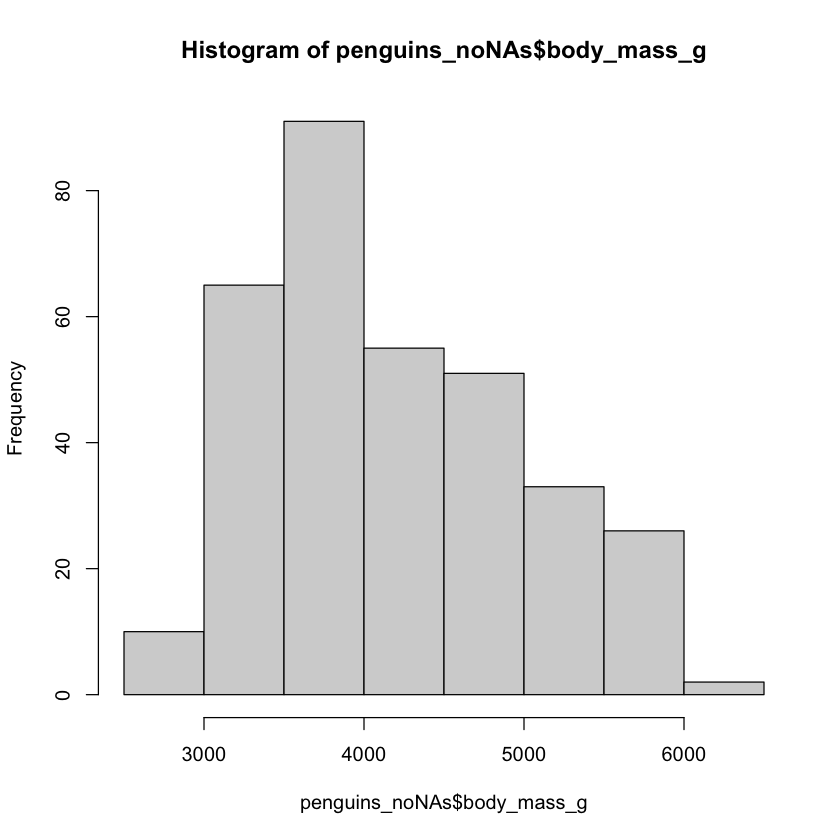

In [35]:
penguins_if_else <- penguins_noNAs %>% 
  mutate(body_mass_g = if_else(species == "Adelie",
                             body_mass_g + 200,
                             as.numeric(body_mass_g)))

hist(penguins_noNAs$body_mass_g)

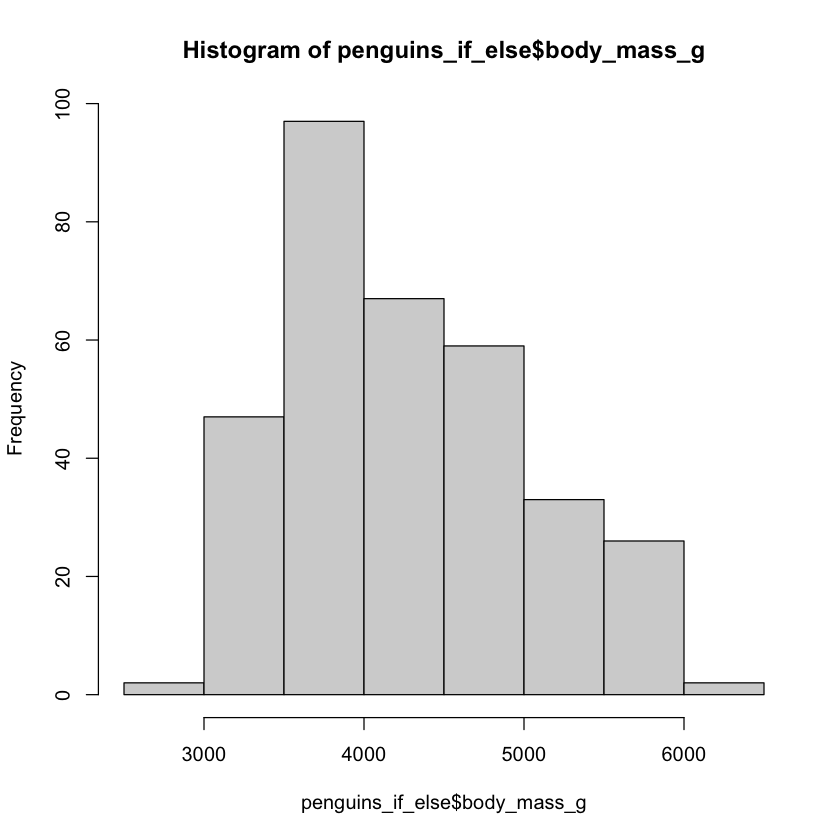

In [36]:
hist(penguins_if_else$body_mass_g)

While fine for one single statement, multiple `if_else()` statements can create horrible code. For this we can use `case_when()`, Where we take a statement, then use **~** to say the new column value, then a comma before the next statement. Maybe Gentoos were also miss-measured but the other way round (too big).

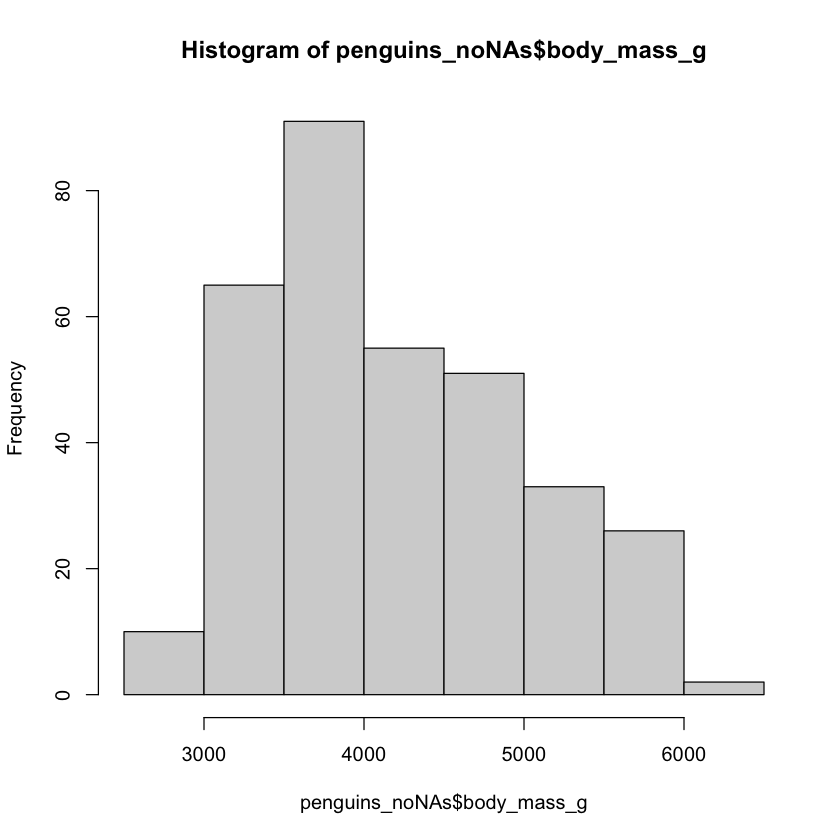

In [37]:
penguins_case_when <- penguins_noNAs %>% 
  mutate(body_mass_g = case_when(species == "Adelie" ~ body_mass_g + 200,
                               species == "Gentoo" ~ body_mass_g - 200,
                               species == "Chinstrap" ~ body_mass_g))

hist(penguins_noNAs$body_mass_g)

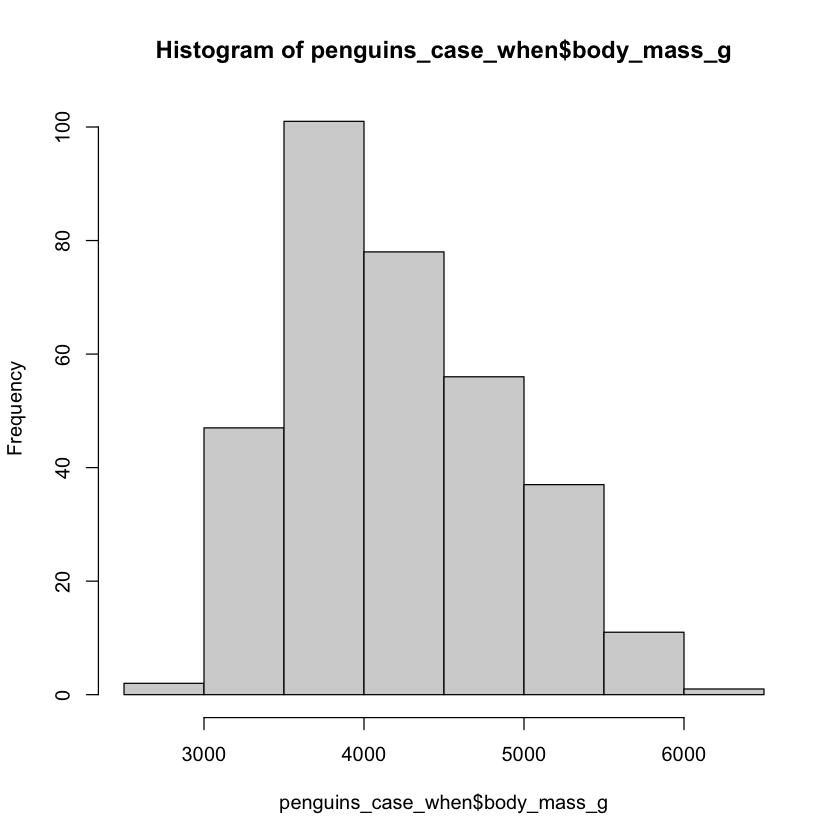

In [38]:
hist(penguins_case_when$body_mass_g)

With `case_when()` we have to be careful if all of our statements don’t cover all the data. If there is a condition not covered it will return NA values. To avoid this we can do a final statement with `TRUE~Our_Default`

In [39]:
penguins_case_when_Missing <- penguins_noNAs %>% 
  mutate(body_mass_g = case_when(species == "Adelie" ~ body_mass_g + 200,
                               species == "Gentoo" ~ body_mass_g - 200))

penguins_case_when_TRUE <- penguins_noNAs %>% 
  mutate(body_mass_g = case_when(species == "Adelie" ~ body_mass_g + 200,
                               species == "Gentoo" ~ body_mass_g - 200,
                               TRUE~body_mass_g))

all.equal(penguins_case_when_TRUE, penguins_case_when_Missing)

[1] "Component “body_mass_g”: 'is.NA' value mismatch: 68 in current 0 in target"

This creates 68 NA values in our data, so need to be aware of this. But we could use it for bug checking.

### Summarise

Often times we will want to summarise the data with some descriptive statistics across groups. Using a combination of `group_by()` and `summarise()` can give us these summary stats. We can group by one, two or many columns, the more groups the less data will summarised in each group. If we don’t group by a column it will not be in the final dataset.

In [40]:
penguins_noNAs %>% 
  group_by(year) %>% 
  summarise(Mean_body_mass = mean(body_mass_g))

year,Mean_body_mass
<int>,<dbl>
2007,4153.155
2008,4263.274
2009,4200.214


In [41]:
penguins_noNAs %>% 
  group_by(year, species) %>% 
  summarise(Mean_body_mass = mean(body_mass_g))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year and species.
ℹ Output is grouped by year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


year,species,Mean_body_mass
<int>,<fct>,<dbl>
2007,Adelie,3714.205
2007,Chinstrap,3694.231
2007,Gentoo,5100.000
2008,Adelie,3742.000
2008,Chinstrap,3800.000
2008,Gentoo,5027.778
2009,Adelie,3664.904
2009,Chinstrap,3725.000
2009,Gentoo,5157.317


In [42]:
penguins_noNAs %>% 
  group_by(year, species, island) %>% 
  summarise(Mean_body_mass = mean(body_mass_g))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, and island.
ℹ Output is grouped by year and species.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


year,species,island,Mean_body_mass
<int>,<fct>,<fct>,<dbl>
2007,Adelie,Biscoe,3620.000
2007,Adelie,Dream,3707.895
2007,Adelie,Torgersen,3785.000
2007,Chinstrap,Dream,3694.231
2007,Gentoo,Biscoe,5100.000
2008,Adelie,Biscoe,3627.778
2008,Adelie,Dream,3756.250
2008,Adelie,Torgersen,3856.250
2008,Chinstrap,Dream,3800.000


In [43]:
penguins_noNAs %>% 
  group_by(year, species, island, sex) %>% 
  summarise(Mean_body_mass = mean(body_mass_g))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, island, and sex.
ℹ Output is grouped by year, species, and island.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island, sex))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


year,species,island,sex,Mean_body_mass
<int>,<fct>,<fct>,<fct>,<dbl>
2007,Adelie,Biscoe,female,3470.000
2007,Adelie,Biscoe,male,3770.000
2007,Adelie,Dream,female,3269.444
2007,Adelie,Dream,male,4102.500
2007,Adelie,Torgersen,female,3475.000
2007,Adelie,Torgersen,male,4139.286
2007,Chinstrap,Dream,female,3569.231
2007,Chinstrap,Dream,male,3819.231
2007,Gentoo,Biscoe,female,4618.750


We can also use groups to count numbers of rows within each group. Although the `table()` function in base R does the same but it is harder to read and use when lots of columns selected.

In [44]:
penguins_noNAs %>% 
  group_by(year, species, island, sex) %>% 
  summarise(Number = n())

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, island, and sex.
ℹ Output is grouped by year, species, and island.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island, sex))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


year,species,island,sex,Number
<int>,<fct>,<fct>,<fct>,<int>
2007,Adelie,Biscoe,female,5
2007,Adelie,Biscoe,male,5
2007,Adelie,Dream,female,9
2007,Adelie,Dream,male,10
2007,Adelie,Torgersen,female,8
2007,Adelie,Torgersen,male,7
2007,Chinstrap,Dream,female,13
2007,Chinstrap,Dream,male,13
2007,Gentoo,Biscoe,female,16


In [45]:
penguins_noNAs %>% 
  select(year, species, island, sex) %>% 
  table()

, , island = Biscoe, sex = female

      species
year   Adelie Chinstrap Gentoo
  2007      5         0     16
  2008      9         0     22
  2009      8         0     20

, , island = Dream, sex = female

      species
year   Adelie Chinstrap Gentoo
  2007      9        13      0
  2008      8         9      0
  2009     10        12      0

, , island = Torgersen, sex = female

      species
year   Adelie Chinstrap Gentoo
  2007      8         0      0
  2008      8         0      0
  2009      8         0      0

, , island = Biscoe, sex = male

      species
year   Adelie Chinstrap Gentoo
  2007      5         0     17
  2008      9         0     23
  2009      8         0     21

, , island = Dream, sex = male

      species
year   Adelie Chinstrap Gentoo
  2007     10        13      0
  2008      8         9      0
  2009     10        12      0

, , island = Torgersen, sex = male

      species
year   Adelie Chinstrap Gentoo
  2007      7         0      0
  2008      8        

### Wide and long formatted data

Tidy data is generally in what could be considered a long format, where each row is an individial observations often having a column that repeats itself. The opposite of long data are wide data. If you ever come across a dataset that is wider than it is long, then it is probably because the person that created it saved one variable across many columns. Some visualisation tools or tables might be better to be in wide formats.

Lets take some of the summaries from above to create a wide database from our last summary which was hard to read because of its length. To go between wide and long data we will use pivot functions from `{tidyr}`, namely `pivot_wider()` and `pivot_longer()`.

In [46]:
penguins_noNAs %>% 
  group_by(year, species, island, sex) %>% 
  summarise(Mean_body_mass = mean(body_mass_g)) %>% 
  pivot_wider(names_from = species, values_from = Mean_body_mass)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, island, and sex.
ℹ Output is grouped by year, species, and island.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island, sex))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


year,island,sex,Adelie,Chinstrap,Gentoo
<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2007,Biscoe,female,3470.000,NA,4618.750
2007,Biscoe,male,3770.000,NA,5552.941
2007,Dream,female,3269.444,3569.231,NA
2007,Dream,male,4102.500,3819.231,NA
2007,Torgersen,female,3475.000,NA,NA
2007,Torgersen,male,4139.286,NA,NA
2008,Biscoe,female,3244.444,NA,4627.273
2008,Biscoe,male,4011.111,NA,5410.870
2008,Dream,female,3412.500,3472.222,NA


It is still quite long but we could also add more info into the wider columns (e.g. year or sex)

In [47]:
penguins_noNAs %>% 
  group_by(year, species, island, sex) %>% 
  summarise(Mean_body_mass = mean(body_mass_g)) %>% 
  pivot_wider(names_from = c(species, year), values_from = Mean_body_mass)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, island, and sex.
ℹ Output is grouped by year, species, and island.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island, sex))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


island,sex,Adelie_2007,Chinstrap_2007,Gentoo_2007,Adelie_2008,Chinstrap_2008,Gentoo_2008,Adelie_2009,Chinstrap_2009,Gentoo_2009
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Biscoe,female,3470.000,NA,4618.750,3244.444,NA,4627.273,3446.875,NA,4786.250
Biscoe,male,3770.000,NA,5552.941,4011.111,NA,5410.870,4268.750,NA,5510.714
Dream,female,3269.444,3569.231,NA,3412.500,3472.222,NA,3357.500,3522.917,NA
Dream,male,4102.500,3819.231,NA,4100.000,4127.778,NA,3945.000,3927.083,NA
Torgersen,female,3475.000,NA,NA,3518.750,NA,NA,3193.750,NA,NA
Torgersen,male,4139.286,NA,NA,4193.750,NA,NA,3784.375,NA,NA


In [48]:
penguins_noNAs %>% 
  group_by(year, species, island, sex) %>% 
  summarise(Mean_body_mass = mean(body_mass_g)) %>% 
  pivot_wider(names_from = c(species, sex), values_from = Mean_body_mass)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, island, and sex.
ℹ Output is grouped by year, species, and island.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island, sex))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


year,island,Adelie_female,Adelie_male,Chinstrap_female,Chinstrap_male,Gentoo_female,Gentoo_male
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2007,Biscoe,3470.000,3770.000,NA,NA,4618.750,5552.941
2007,Dream,3269.444,4102.500,3569.231,3819.231,NA,NA
2007,Torgersen,3475.000,4139.286,NA,NA,NA,NA
2008,Biscoe,3244.444,4011.111,NA,NA,4627.273,5410.870
2008,Dream,3412.500,4100.000,3472.222,4127.778,NA,NA
2008,Torgersen,3518.750,4193.750,NA,NA,NA,NA
2009,Biscoe,3446.875,4268.750,NA,NA,4786.250,5510.714
2009,Dream,3357.500,3945.000,3522.917,3927.083,NA,NA
2009,Torgersen,3193.750,3784.375,NA,NA,NA,NA


Often as ecologists we will be surveying a whole community and counting numbers of each different species at each site. This data often comes to us as wide data, our summary of counts could be turned into a wide df (we will fill NAs as 0s) and we can the convert it back to a long dataframe.

In [50]:
WideCounts <- penguins_noNAs %>% 
  group_by(year, species, island, sex) %>% 
  summarise(Number = n()) %>% 
  pivot_wider(names_from = species,values_from = Number, values_fill = 0)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, species, island, and sex.
ℹ Output is grouped by year, species, and island.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, species, island, sex))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


In [51]:
WideCounts

year,island,sex,Adelie,Chinstrap,Gentoo
<int>,<fct>,<fct>,<int>,<int>,<int>
2007,Biscoe,female,5,0,16
2007,Biscoe,male,5,0,17
2007,Dream,female,9,13,0
2007,Dream,male,10,13,0
2007,Torgersen,female,8,0,0
2007,Torgersen,male,7,0,0
2008,Biscoe,female,9,0,22
2008,Biscoe,male,9,0,23
2008,Dream,female,8,9,0


Okay so we now have a count of different sexes of species of penguins measured in different years and islands. Lets make this data long, to do this we have to tell the function which columns are to be pivoted, and what we want to call the new columns.

We can either tell it which columns should or should not be pivoted, or we can even say which position columns to use with numbers (using the colon means from one thing to the other thing).

In [52]:
LongCounts_1 <- WideCounts %>% 
  pivot_longer(c(Adelie, Chinstrap, Gentoo), names_to = "species", values_to = "Number")

LongCounts_2 <- WideCounts %>% 
  pivot_longer(-c(year, island, sex), names_to = "species", values_to = "Number")

LongCounts_3 <- WideCounts %>% 
  pivot_longer(4:6, names_to = "species", values_to = "Number")

LongCounts_4 <- WideCounts %>% 
  pivot_longer(-c(1:3), names_to = "species", values_to = "Number")

Lets check they are all the same to finish off.

In [53]:
all.equal(
  LongCounts_1,
  LongCounts_2
)

[1] TRUE

In [54]:
all.equal(
  LongCounts_3,
  LongCounts_4
)

[1] TRUE

In [55]:
all.equal(
  LongCounts_3,
  LongCounts_4
)

[1] TRUE

In [56]:
all.equal(
  LongCounts_1,
  LongCounts_4
)

[1] TRUE

### Why all of this?

One might wonder why do we do all of this. It is all well and good to see that we can tidy data in R, but could the same not be done quicker in MS Excel? Well, yes, with a small dataset it can be done quickly in MS Excel. But remember that for many, the reason to learn R is to ensure that you are performing reproducible research. This means tgat every step in our workflow must be documented. And this can be accomplished by writing R scripts, and part of the purpose of these scripts is to ensure that you capture all the steps taken to get the raw data into a neat, tidy format that can unambiguously be read into R in the format that will quickly get you up and running with your analysis and visualisations.